In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
prostate_df=pd.read_csv('prostate.data', delimiter='\t')
prostate_data=prostate_df.drop('ID',axis=1)
prostate_data.head()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa,train
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783,T
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519,T
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519,T
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519,T
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564,T


In [5]:
'''
features explained:
lcavol: log cancer volume;
lweight: log prostate weight
age: age
lbph: log of the amount of bengin prostatic hyperplasia
svi: log of capsular penetration
gleason: gleason score
pgg45: percent of the gleason score 4 or 5
lpsa: log of prostate_specfic antigen ----------------->predict target
train: train/test indicator
'''
target = 'lpsa'
# based on the following features
features = ['lcavol', 'lweight', 'age', 'lbph',
            'svi', 'lcp', 'gleason', 'pgg45']

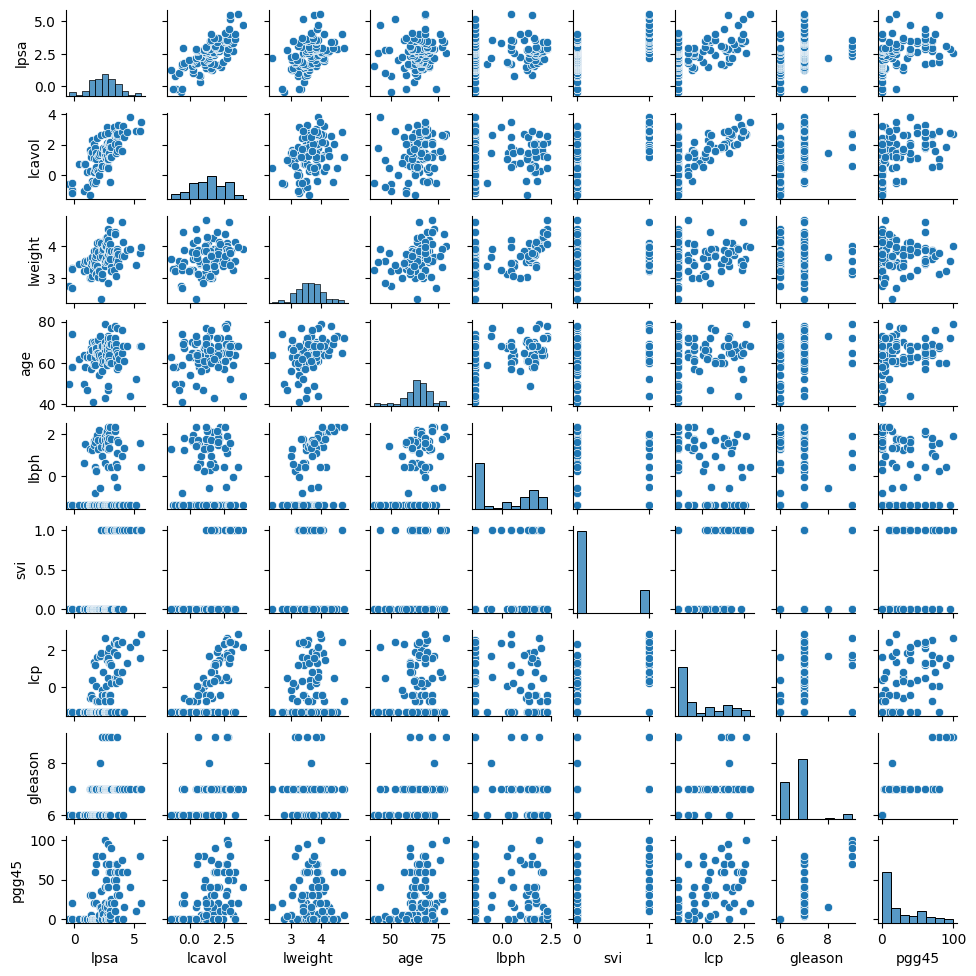

In [6]:
import warnings
warnings.filterwarnings('ignore', '.*use_inf_as_na.*')
sns.pairplot(prostate_data, vars=[target]+features, kind="scatter", height=1.1)

In [7]:
#分析相关性矩阵
prostate_corr=prostate_data[[target]+features].corr()
prostate_corr.head(9)

,lpsa,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45
lpsa,1.000000,0.734460,0.433319,0.169593,0.179809,0.566218,0.548813,0.368987,0.422316
lcavol,0.734460,1.000000,0.280521,0.225000,0.027350,0.538845,0.675310,0.432417,0.433652
lweight,0.433319,0.280521,1.000000,0.347969,0.442264,0.155385,0.164537,0.056882,0.107354
age,0.169593,0.225000,0.347969,1.000000,0.350186,0.117658,0.127668,0.268892,0.276112
lbph,0.179809,0.027350,0.442264,0.350186,1.000000,-0.085843,-0.006999,0.077820,0.078460
svi,0.566218,0.538845,0.155385,0.117658,-0.085843,1.000000,0.673111,0.320412,0.457648
lcp,0.548813,0.675310,0.164537,0.127668,-0.006999,0.673111,1.000000,0.514830,0.631528
gleason,0.368987,0.432417,0.056882,0.268892,0.077820,0.320412,0.514830,1.000000,0.751905
pgg45,0.422316,0.433652,0.107354,0.276112,0.078460,0.457648,0.631528,0.751905,1.000000


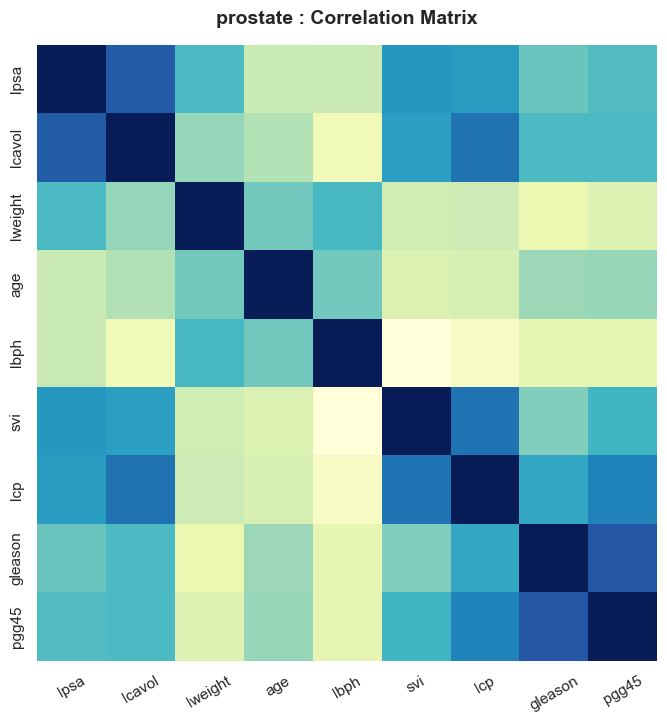

In [8]:
#画出相关性矩阵的热图更加直观
sns.set(rc={'figure.figsize':(8,8)})
# Visually display the matrix from above
# use the yellow-green-blue color map so that high correlations are more easily identifiable
h = sns.heatmap(prostate_corr, annot=False, cmap="YlGnBu", cbar=False)

# Add plot title 
h.set_title('prostate : Correlation Matrix', size=14, weight='bold', pad=15)

# rotate tick marks so they are easier to read
plt.xticks(rotation=30)

# Display plot
plt.show()

**可以发现和age,lbph的相关性并不是很高，但是先保留**  
接下来对数据集进行分割  

In [9]:
# 先分别创建训练集和测试集的DataFrame
df_train = prostate_data[prostate_data['train'] == 'T']
df_test = prostate_data[prostate_data['train'] != 'T']
# 然后对这两个DataFrame，分别抽取特征值和目标值
'''
X_train_u实际是X_train_untransformed
y不用transform
'''
X_train_u, y_train = df_train[features].values, df_train[target].values
X_test_u, y_test = df_test[features].values, df_test[target].values

In [10]:
#对数据进行标准化处理
#只需要对features进行处理就好了
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train_u)
X_test=scaler.transform(X_test_u)

In [11]:
#定义一个计算R^2的函数
#TSS = ∑(yi - y_mean)²，RSS = ∑(yi - ŷi)²
#rsquared=1-rss/tss
def rsquared(y_train,y_pred):
    rss=sum((y_train-y_pred)**2)
    tss=sum((y_train-np.mean(y_train))**2)
    rsquared=1-rss/tss
    return rsquared

#定义调整决定系数函数调整决定系数（Adjusted R-squared）的计算公式是：
#AdjR^2 = 1 - [(1 - R^2)(n - 1) / (n - k - 1)]
def adjrsquared(y_train,y_pred,k):
    '''parameters:
    k:feature numbers
    '''
    rsq=rsquared(y_train,y_pred)
    n=len(y_train)
    adjrsq=1-(1-rsq)*(n-1)/(n-k-1)
    return adjrsq

In [24]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.dummy import DummyRegressor
class OneStandardErrorRuleModel:
   
    def __init__(self, estimator, param_name, param_values,
                 force_model_idx=None, n_folds=10,
                 is_regression=True, random_state=69438):
        self.n_folds = n_folds
        self.estimator = estimator
        self.param_name = param_name
        self.param_values = param_values
        self.force_model_idx = force_model_idx
        self.is_regression = is_regression
      
            estimator, {param_name: param_values},
            cv=KFold(n_splits=n_folds, shuffle=True, random_state=random_state),
            scoring='neg_mean_squared_error' if is_regression else 'accuracy',
            return_train_score=True)

    def fit(self, X, y) :
        self.grid_search.fit(X, y)

        cv_errors = -np.vstack(
            [self.grid_search.cv_results_[f'split{i}_test_score']
             for i in range(self.n_folds)]).T
        if not self.is_regression:
            cv_errors = 1 + cv_errors
       
        self.cv_mean_errors_ = np.mean(cv_errors, axis=1)
        self.cv_mean_errors_std_ = \
            np.std(cv_errors, ddof=1, axis=1) / np.sqrt(self.n_folds)

        self.best_model_idx_ = np.argmin(self.cv_mean_errors_)
        self.cv_min_error_ = self.cv_mean_errors_[self.best_model_idx_]
        self.cv_min_error_std_ = self.cv_mean_errors_std_[self.best_model_idx_]
       
        error_threshold = self.cv_min_error_ + self.cv_min_error_std_
        self.model_idx_ = np.argmax(self.cv_mean_errors_ < error_threshold)
        return self.__fit_to_all_data(X, y)

    def refit(self, X, y,
              force_model_idx=None) :
        self.force_model_idx = force_model_idx
        return self.__fit_to_all_data(X, y)

    def __fit_to_all_data(self, X, y):
        if self.force_model_idx is not None:
            self.model_idx_ = self.force_model_idx
        self.model_ = self.estimator
        self.model_.set_params(
            **{self.param_name: self.param_values[self.model_idx_]})
        self.model_.fit(X, y)
        return self

    def predict(self, X):
        return np.squeeze(self.model_.predict(X))
    def r2score(self,X,y):
        y_hat = self.predict(X)
        q=rsquared(y,y_hat)
        return q

    def assess(self, X, y) :
        """Calculate mean error of the model and its standard error on the
           specified data."""
        y_hat = self.predict(X)
        errors = (y-y_hat)**2 if self.is_regression else 1.0*(y != y_hat)
        error = np.mean(errors)
        error_std = np.std(errors, ddof=1) / np.sqrt(y.size)
        return error, error_std
# linear zero-complexity model is the model that predicts the mean target value
# let's run our class in order to find it's mean CV error and its standard
# error this information will be used in plotting
baseline = OneStandardErrorRuleModel(
    DummyRegressor(), 'constant', [None]
).fit(X_train, y_train)
# plots the model selection results, "complexities" could contain x axis ticks
# for example, Ridge regression is regularized by "alpha" parameter, but
# it is assumed that we regularize the "degrees of freedom"
def plot_cv_results(title, x_label, model, complexities: list[float] = None):
    if complexities is None:
        complexities = model.param_values
    complexities = [0] + complexities
    means = np.hstack((baseline.cv_mean_errors_, model.cv_mean_errors_))
    stds = np.hstack((baseline.cv_mean_errors_std_, model.cv_mean_errors_std_))
    fig, ax = plt.subplots(figsize=(4, 3.1), dpi=110)
    ax.plot(complexities, means, c='orange', linewidth=0.8)
    ax.errorbar(
        complexities, means, color='orange', linestyle='None', marker='o',
        elinewidth=0.8, markersize=3, yerr=stds, ecolor='blue', capsize=3)
    ax.axhline(y=model.cv_min_error_ + model.cv_min_error_std_,
               c='purple', linewidth=0.8, linestyle='--')
    ax.axvline(x=complexities[model.model_idx_ + 1],
               c='purple', linewidth=0.8, linestyle='--')
    for i in ax.get_yticklabels() + ax.get_xticklabels():
        i.set_fontsize(6)
    ax.text(ax.get_xlim()[0], 1.85, title, color='gray', fontsize=9)
    ax.set_xlabel(x_label, color='gray', fontsize=8)
    ax.set_ylabel('CV Error', color='gray', fontsize=8)
    parms = {'color': 'gray', 'fontsize': 7,
             'bbox': {'facecolor': 'white', 'pad': 0, 'edgecolor': 'none'}}
    lim = ax.get_xlim()
    text_x = lim[1] - (lim[1]-lim[0])*0.02
    test_error, test_error_std = model.assess(X_test, y_test)
    ax.text(text_x, 1.72, f'Test Error:  {test_error:.3f}',
            **parms, ha='right')
    ax.text(text_x, 1.63, f' Std Error:  {test_error_std:.3f}',
            **parms, ha='right')

**------------------------------------------------------------------------------分割线------------------------------------------------------------------**   
上面的是数据预处理部分，下面是各种独立的算法，如果想运行某一种算法实现的框架，请先运行上面的，然后再去运行对应算法的代码节就好了

 # 1.简单的多元线性回归   
采用了最小二乘估计法（OLS）  

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error


lr=LinearRegression().fit(X_train,y_train)
# 获取斜率（系数）和截距
coef = lr.coef_
icp = lr.intercept_

#获得了截距和斜率之后要预测

y_pred=lr.predict(X_test)
y_pred_trainset=lr.predict(X_train)

#R^2
R2=rsquared(y_train,y_pred_trainset)

#MSE
mse = mean_squared_error(y_test, y_pred)

#MAE
mae=mean_absolute_error(y_test,y_pred)

print('------------OLS-----------')
print('MAE         MSE        R^2')
print(f'{mae:>3.3f}{mse:>12.3f}{R2:>10.2f}')


------------OLS-----------
MAE         MSE        R^2
0.523       0.521      0.69


# 2.Lasso regression

0.5687901664250632


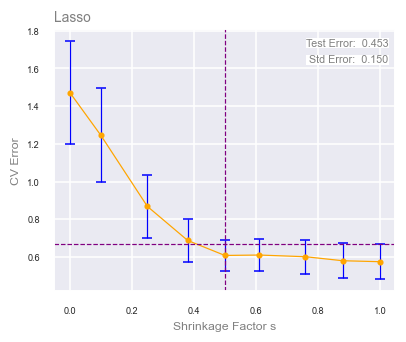

In [39]:

from sklearn.linear_model import  Lasso
lasso_regression = OneStandardErrorRuleModel(
    Lasso(), 'alpha',
    [0.700, 0.40, 0.23, 0.100, 0.044, 0.027, 0.012, 0.001]
).fit(X_train, y_train)
# save model parameters as 1D vector
lasso_params = np.hstack((lasso_regression.model_.intercept_,
                          lasso_regression.model_.coef_))
plot_cv_results('Lasso', 'Shrinkage Factor s', lasso_regression,
                [0.1, 0.25, 0.38, 0.50, 0.61, 0.76, 0.88, 1])
r2scores=lasso_regression.r2score(X_test,y_test)
print(r2scores)

ValueError: Invalid parameter 'alpha' for estimator LinearRegression(). Valid parameters are: ['copy_X', 'fit_intercept', 'n_jobs', 'positive'].